# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings("ignore")

# Load and prepare data

In [2]:
def load_and_clean():
    df = pd.read_excel('data/dataset_MIGRATION.xlsx')

    print(df.head())
    print(df.info())
    print(df.describe())
    df_nationalities = df['Громадянство'].value_counts()
    df_territorial = df['Територіальний розріз'].value_counts()
    print(df_nationalities.head())
    print(df_territorial.head())

    period_cols = [
        c for c in df.columns if isinstance(c, str) and (c.isdigit() or '-' in c and c.split('-')[0].isdigit())
    ]

    clean_df = df.melt(['Територіальний розріз', 'Країна в\'їзду/виїзду', 'Стать', 'Вік'],
                       value_vars=period_cols,
                       var_name='Period',
                       value_name='Migrants')
    clean_df['Period'] = pd.to_datetime(clean_df['Period'], format='%Y-%m', errors='coerce').fillna(pd.to_datetime
                                                                                                    (clean_df[
                                                                                                         'Period'].str[
                                                                                                         :4],
                                                                                                     format='%Y',
                                                                                                     errors='coerce'))
    clean_df = clean_df.dropna(subset=['Period'])
    clean_df = clean_df.rename(columns={
        'Територіальний розріз': 'District',
        "Країна в'їзду/виїзду": 'Country',
        'Стать': 'Gender',
        'Вік': 'Age'
    })
    for col in ['Gender', 'Age']:
        clean_df[col] = clean_df[col].replace('Усього', np.nan)

    clean_df.dropna(inplace=True)
    return clean_df


df = load_and_clean()

                          Показник      Територіальний розріз Тип місцевості  \
0  Кількість прибулих (всі потоки)                  Вінницька        Загалом   
1  Кількість прибулих (всі потоки)  Автономна Республіка Крим        Загалом   
2  Кількість прибулих (всі потоки)                    Україна        Загалом   
3  Кількість прибулих (всі потоки)                    Україна        Загалом   
4  Кількість прибулих (всі потоки)                  Вінницька        Загалом   

      Стать          Вік Країна в'їзду/виїзду Громадянство Країна народження  \
0     Жінки    5-9 років               Усього       Усього            Усього   
1    Усього   80-84 роки               Усього       Усього            Усього   
2     Жінки   70-74 роки               Усього       Усього            Усього   
3  Чоловіки       Усього               Усього       Усього            Усього   
4     Жінки  25-29 років               Усього       Усього            Усього   

  Періодичність Одиниця виміру  ... 20

# FORECAST

In [3]:
def es_forecast(series: pd.Series, periods: int, seasonal_periods=None):
    y = series.dropna()

    if len(y) < 6:
        fc_values = np.repeat(y.mean(), periods)
    else:
        model = ExponentialSmoothing(
            y,
            trend='add',
            seasonal='add' if seasonal_periods else None,
            seasonal_periods=seasonal_periods
        ).fit()
        fc_values = model.forecast(periods)

    last_date = y.index[-1]
    if y.index.freq is None:
        y = y.asfreq('MS') if seasonal_periods else y.asfreq('Y')

    fc_index = pd.date_range(
        start=last_date + y.index.freq,
        periods=periods,
        freq=y.index.freq
    )

    return pd.Series(fc_values, index=fc_index)



def forecast_bottom_up_grouped(df, group_col, months=12, years=5):
    # Monthly
    monthly = df.copy().set_index('Period').sort_index()
    region_fc_monthly = []

    for key, sub in monthly.groupby(group_col):
        s = sub['Migrants'].resample('MS').sum()

        fc = es_forecast(s, periods=months, seasonal_periods=12)
        df_fc = pd.DataFrame({
            group_col: key,
            'Period': fc.index,
            'Forecast': fc.values
        })
        region_fc_monthly.append(df_fc)

    region_fc_monthly = pd.concat(region_fc_monthly)
    country_fc_monthly = region_fc_monthly.groupby('Period')['Forecast'].sum().reset_index()

    # Yearly
    region_fc_yearly_list = []
    for key, sub in df.groupby(group_col):
        s = sub.set_index('Period').resample('Y').sum()['Migrants']

        fc = es_forecast(s, periods=years, seasonal_periods=None)
        df_fc = pd.DataFrame({
            group_col: key,
            'Period': fc.index,
            'Forecast': fc.values
        })
        region_fc_yearly_list.append(df_fc)

    region_fc_yearly = pd.concat(region_fc_yearly_list)
    country_fc_yearly = region_fc_yearly.groupby('Period')['Forecast'].sum().reset_index()

    return region_fc_monthly, country_fc_monthly, region_fc_yearly, country_fc_yearly

# Plots

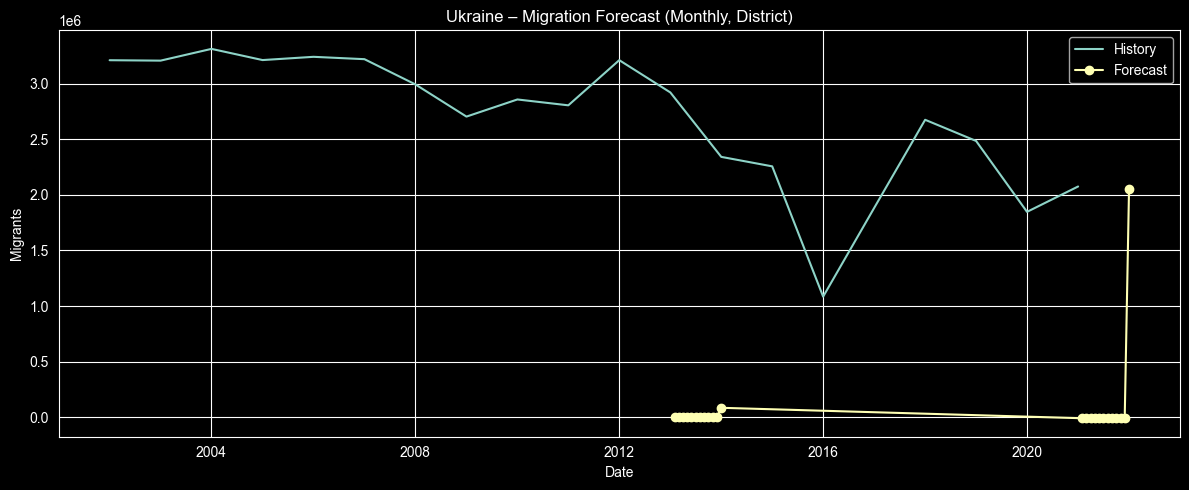

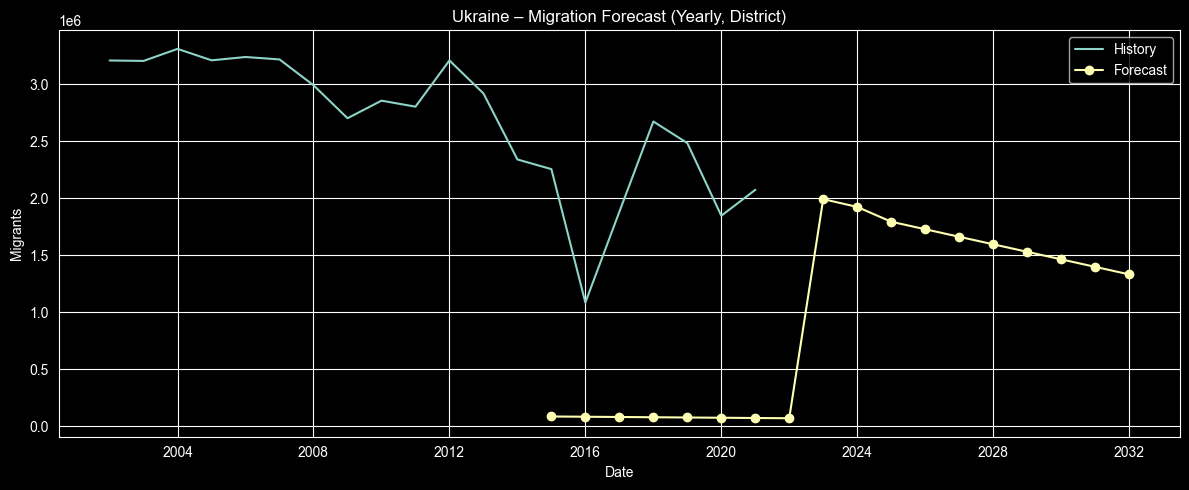

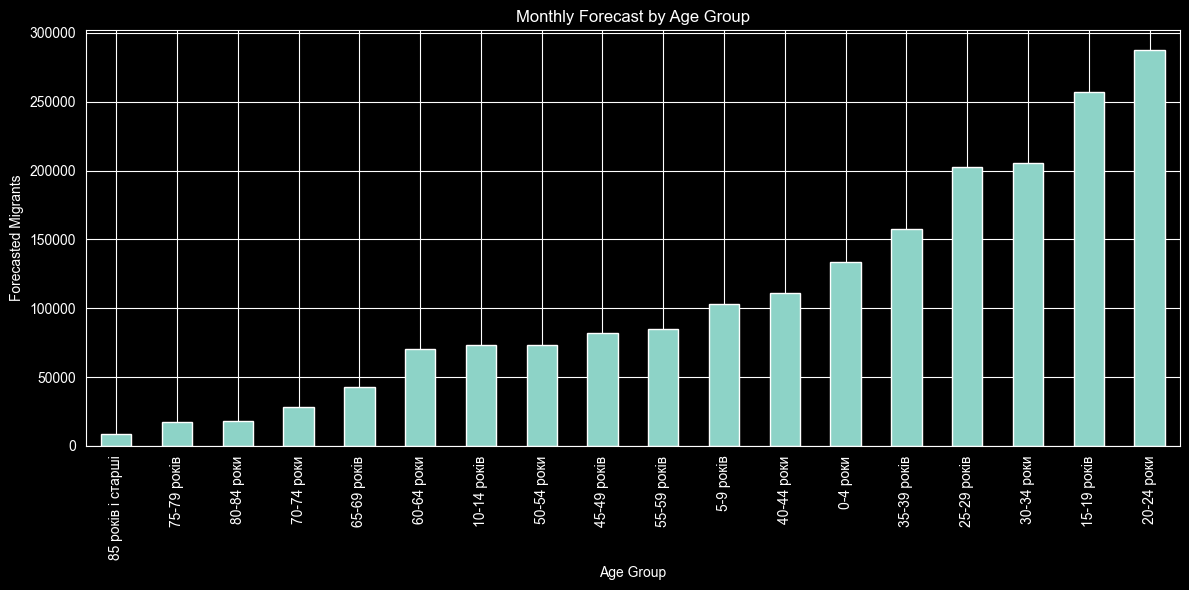

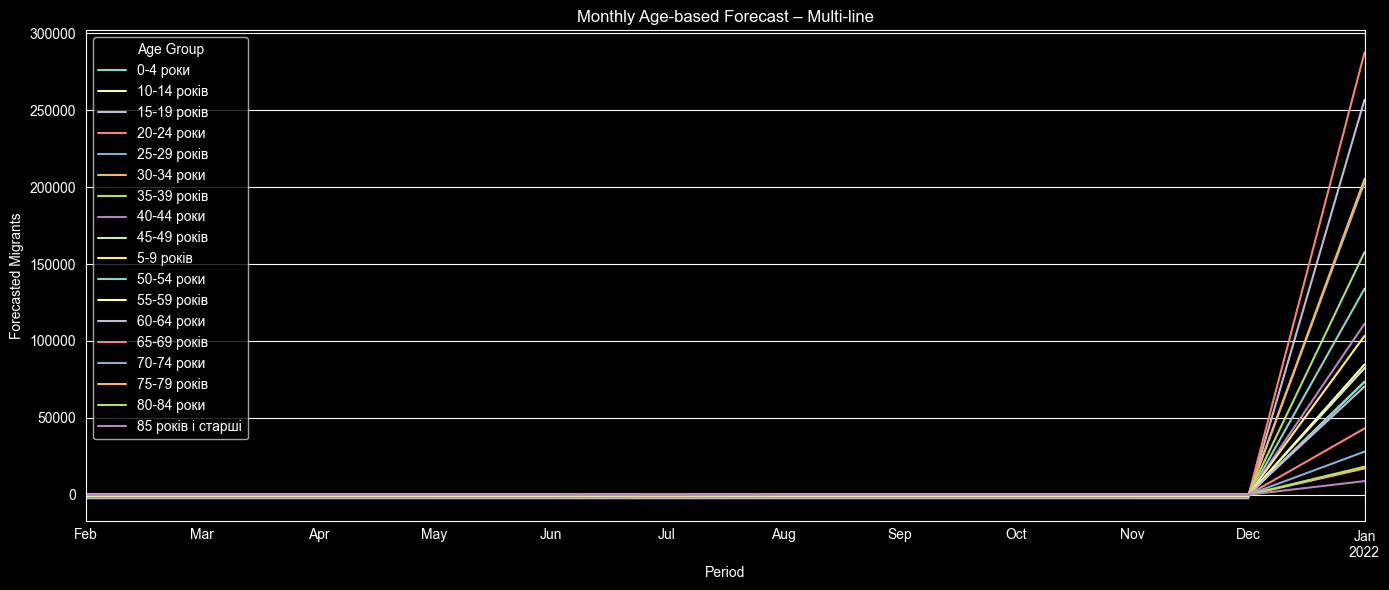

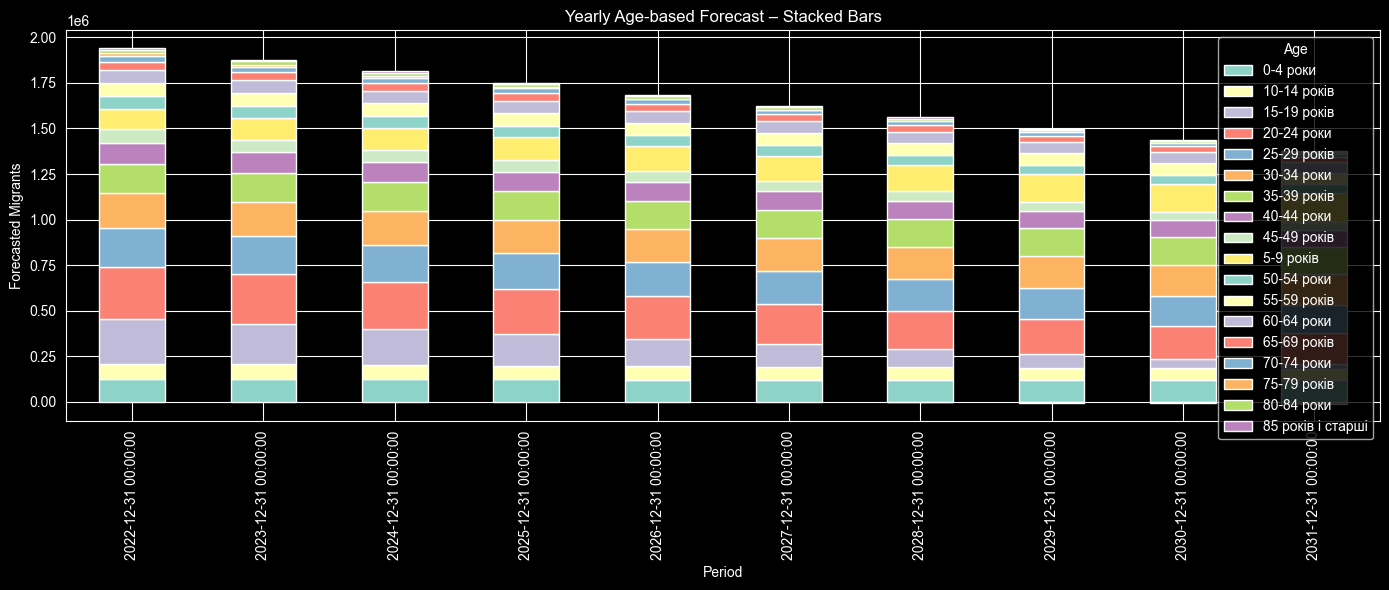

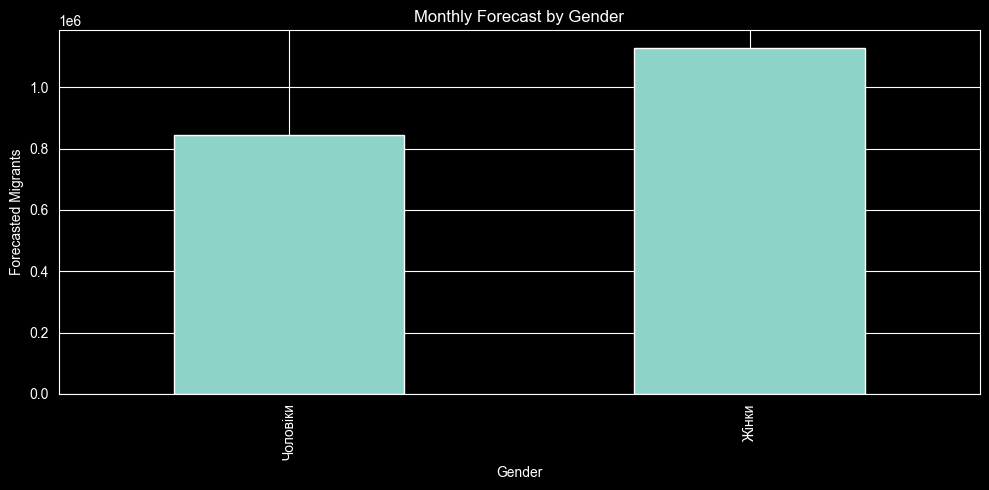

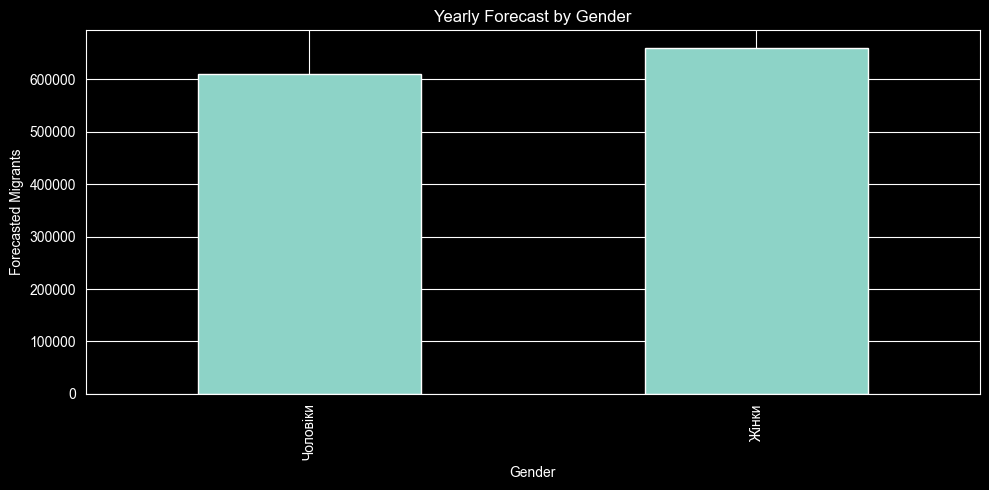

In [4]:
def plot_country_fc(history: pd.DataFrame, fc: pd.DataFrame, title: str):
    hist = history.groupby('Period')['Migrants'].sum()

    plt.figure(figsize=(12, 5))
    plt.plot(hist.index, hist.values, label='History')
    plt.plot(fc['Period'], fc['Forecast'], label='Forecast', marker='o')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Migrants")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_age_bar(fc: pd.DataFrame, title: str):
    latest = fc.groupby('Age')['Forecast'].last().sort_values()

    plt.figure(figsize=(12, 6))
    latest.plot(kind='bar')
    plt.title(title)
    plt.ylabel("Forecasted Migrants")
    plt.xlabel("Age Group")
    plt.tight_layout()
    plt.show()

def plot_age_stacked(fc: pd.DataFrame, title: str):
    pivot = fc.pivot(index="Period", columns="Age", values="Forecast")

    pivot.plot(kind="bar", stacked=True, figsize=(14, 6))
    plt.title(title)
    plt.ylabel("Forecasted Migrants")
    plt.xlabel("Period")
    plt.tight_layout()
    plt.show()

def plot_age_lines(fc: pd.DataFrame, title: str):
    pivot = fc.pivot(index="Period", columns="Age", values="Forecast")

    pivot.plot(figsize=(14, 6))
    plt.title(title)
    plt.ylabel("Forecasted Migrants")
    plt.xlabel("Period")
    plt.legend(title="Age Group")
    plt.tight_layout()
    plt.show()

def plot_gender_bar(fc: pd.DataFrame, title: str):
    latest = fc.groupby('Gender')['Forecast'].last().sort_values()

    plt.figure(figsize=(10, 5))
    latest.plot(kind='bar')
    plt.title(title)
    plt.ylabel("Forecasted Migrants")
    plt.xlabel("Gender")
    plt.tight_layout()
    plt.show()



region_fc_m, country_fc_m, region_fc_y, country_fc_y = forecast_bottom_up_grouped(df, 'District', years=10)
plot_country_fc(df, country_fc_m, 'Ukraine – Migration Forecast (Monthly, District)')
plot_country_fc(df, country_fc_y, 'Ukraine – Migration Forecast (Yearly, District)')

region_fc_m_a, country_fc_m_a, region_fc_y_a, country_fc_y_a = forecast_bottom_up_grouped(df, 'Age', years=10)
plot_age_bar(region_fc_m_a, "Monthly Forecast by Age Group")
plot_age_lines(region_fc_m_a, "Monthly Age-based Forecast – Multi-line")
plot_age_stacked(region_fc_y_a, "Yearly Age-based Forecast – Stacked Bars")

region_fc_m_g, country_fc_m_g, region_fc_y_g, country_fc_y_g = forecast_bottom_up_grouped(df, 'Gender', years=10)
plot_gender_bar(region_fc_m_g, "Monthly Forecast by Gender")
plot_gender_bar(region_fc_y_g, "Yearly Forecast by Gender")